### Construct ti-ureate complexes
In this tutorial, we will use the $\texttt{TM catalyst framework}$ package to generate all the different isomers of a ti-ureate complex.
First we need to import the $\texttt{Complex}$ from the package.
This would be the main function we will use to create the complex.

In [1]:
# import the package
from TM_catalyst_framework.complex import Complex
import os # package for reading, creating and saving files or directories

/opt/anaconda3/envs/TM_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/TM_env/lib/python3.14/site-packages/pybel/io/api.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points


![alt text](figure/figure1.png)

In the first example, we will be constructing a ti-bisureate complex with bidentate ureate ligands.
The complex has six coordination sites, forming an octahedral geometry, with dimethylamido ligands binding to the metal center in the remaining two coordination sites.
To generate the 3D structure of the stereoisomer, you need to:
- Define the geometry of the complex, so the code can load the geometry template internally
- Provide the SMILE stirngs of the ligand(s) that will coordinate the metal center, where for each ligand:
    - Use "*" in the SMILES string to indicate where the ligand would bind to the metal center
    - For bidentate ligands, define which atom is binding to which coordination site



In [2]:
# --------------------------------------------------------------
# Define geometry
# --------------------------------------------------------------
geometry = "octahedral" 

In [20]:
# --------------------------------------------------------------
# Define ligand
# bidentate ligand where nitrogen attaching Ti has two substituents
# --------------------------------------------------------------
from TM_catalyst_framework.complex import Mapping

metal_ligand_coord_map = Mapping(mapping_dict ={})
precursor_ligand = "*N(C)C"
metal_ligand_coord_map.add_monodentate(ligand_SMILES=precursor_ligand,
                                       metal_coord_site=1)

precursor_ligand = "*N(C)C"
metal_ligand_coord_map.add_monodentate(ligand_SMILES=precursor_ligand,
                                       metal_coord_site=6)

ureate_ligand1_SMILES = "CC(N(C)C(N([*])C1=C(C)C=CC=C1C)=O[*])C2=CC=CC=C2"
metal_ligand_coord_map.add_bidentate(ligand_SMILES=ureate_ligand1_SMILES, #The SMILES of the ureate ligand with dummies "*"
                                     atom1 = "O", metal_coord_site1= 2, #Define the first atom on the ligand that is coordinating to Ti, and which coordination site
                                     atom2 = "N", metal_coord_site2= 3#Define the second atom on the ligand that is coordinating to Ti, and which coordination site
                                     )

ureate_ligand2_SMILES = "CC(N(C)C(N([*])C1=C(C)C=CC=C1C)=O[*])C2=CC=CC=C2"
metal_ligand_coord_map.add_bidentate(ligand_SMILES=ureate_ligand2_SMILES, #The SMILES of the ureate ligand with dummies "*"
                                     atom1 = "O", metal_coord_site1= 4, #Define the first atom on the ligand that is coordinating to Ti, and which coordination site
                                     atom2 = "N", metal_coord_site2= 5#Define the second atom on the ligand that is coordinating to Ti, and which coordination site
                                     )
print (metal_ligand_coord_map.mapping_dict)

{1: ['*N(C)C', {'O': 1}], 2: ['*N(C)C', {'O': 6}], 3: ['CC(N(C)C(N([*])C1=C(C)C=CC=C1C)=O[*])C2=CC=CC=C2', {'O': 2, 'N': 3}], 4: ['CC(N(C)C(N([*])C1=C(C)C=CC=C1C)=O[*])C2=CC=CC=C2', {'O': 4, 'N': 5}]}


In [21]:
print (metal_ligand_coord_map.mapping_dict)

{1: ['*N(C)C', {'O': 1}], 2: ['*N(C)C', {'O': 6}], 3: ['CC(N(C)C(N([*])C1=C(C)C=CC=C1C)=O[*])C2=CC=CC=C2', {'O': 2, 'N': 3}], 4: ['CC(N(C)C(N([*])C1=C(C)C=CC=C1C)=O[*])C2=CC=CC=C2', {'O': 4, 'N': 5}]}


In [22]:
# --------------------------------------------------------------
# Define output directory and filename
# --------------------------------------------------------------
output_save_dir = "./geometry_output_sdf/" # define the directory where the output file will be saved.
if os.path.isdir(output_save_dir) != True: # check if the directory exists
    os.mkdir(output_save_dir)               # create directory if it doesn't exist
output_sdf = output_save_dir+f"u2_d2d2_iso1_product_N2.sdf"     #Define the output file name, which will be saved as .sdf format


# initialize the complex by defining the metal center identity
create_complex = Complex(metal_center="Ti", # must
                         force_field = "uff", # optional 
                         force_field_steps = 3000 # optional
                         )

# Create the geometry
create_complex.add_ligands_wt_geometry(geometry,
                                       output_sdf=output_sdf,
                                       metal_coord_dummy_map= metal_ligand_coord_map.mapping_dict,
                                       )

True
Molecule with 7 atoms
Fragment attachment at index 1
Initial energy: 116715.18 kcal/mol
Final energy: 93.93 kcal/mol
Fragment attachment at index 1
Initial energy: 21622.33 kcal/mol
Final energy: 341.74 kcal/mol
Initial energy: 40978716806720.53 kcal/mol
Final energy: 10828.11 kcal/mol
Initial energy: 1385644122478.98 kcal/mol
Final energy: 16345.65 kcal/mol
Initial energy: 16345.65 kcal/mol
Final energy: 15921.39 kcal/mol
Initial energy: 15921.39 kcal/mol
Final energy: 3307.86 kcal/mol
Success! Saved to ./geometry_output_sdf/u2_d2d2_iso1_product_N2.sdf


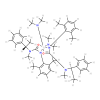

In [23]:
# you can see the 2D projection of the complex by calling .complex:
create_complex.complex

In [24]:
# Alternatively, you can also use the mol_visual module to view the 3D strucutre of the sdf file 
from TM_catalyst_framework.io_utils import mol_visual
mol_3d = mol_visual.visualize_sdf_molecule(output_sdf)
mol_3d

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

True
Molecule with 7 atoms
Fragment attachment at index 1
Initial energy: 127719.81 kcal/mol
Final energy: 15761.64 kcal/mol


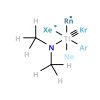

In [6]:
import importlib
from TM_catalyst_framework import Complex
# In case you want to load the template separately
from TM_catalyst_framework.metal_template import load_ti_template_sdf

template = load_ti_template_sdf(f"{geometry}.sdf", 
                                package = "openbabel", 
                                template_dir = "TM_catalyst_framework.template")
create_complex = Complex(metal_center="Ti", force_field = "uff")

# you can just add monodentate ligand yourself
mol = create_complex.attach_monodentate_ligand(template,
                                         precursor_ligand,
                                         coord_site=1, 
                                         halogen_mapping = True
                                         )
mol

Initial energy: 58852713083656.52 kcal/mol
Final energy: 115408.21 kcal/mol


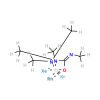

In [7]:
# Followed by adding the bidentate ligand yourself
ureate_ligand1_SMILES = "C/N=C([N](C)(C)[*])/O[*]"
create_complex.attach_bidentate_ligand(mol,
                                       ureate_ligand1_SMILES,
                                       {"O":2, "N":3}, # You would need to define the mapping 
                                         )
create_complex.complex

In [9]:
mol_3d